Lowest energy: -6.7587488
Last energy: -6.7587488
D (difference between last and lowest energy): 0.0 ev


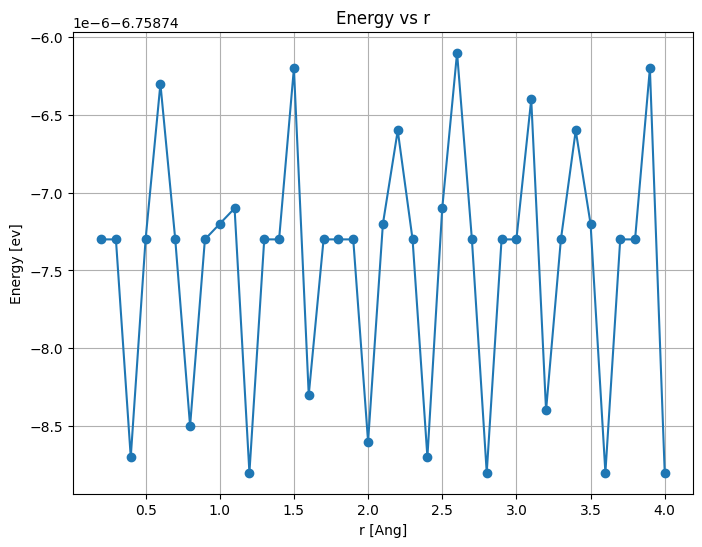

In [1]:
import matplotlib.pyplot as plt

# Initialize lists to store r values and F (energy) values
r_values = []
energy_values = []

# Read the file
with open('energy.dat', 'r') as file:
    for line in file:
        # Split the line by whitespace to access elements
        parts = line.split()
        
        # Extract r from the first column
        r = float(parts[0])  # r value
        
        # Find the 'F=' and capture the energy value after it
        energy_str = line.split('F=')[1].split()[0]  # Extract the string after 'F=' up to the next space
        energy = float(energy_str)  # Convert it to a float
        
        # Append values to respective lists
        r_values.append(r)
        energy_values.append(energy)

# Calculate D
lowest_energy = min(energy_values)
last_energy = energy_values[-1]
D = last_energy - lowest_energy

# Output the result
print(f"Lowest energy: {lowest_energy}")
print(f"Last energy: {last_energy}")
print(f"D (difference between last and lowest energy): {D} ev")

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(r_values, energy_values, marker='o', linestyle='-')
plt.xlabel('r [Ang]')
plt.ylabel('Energy [ev]')
plt.title('Energy vs r')
plt.grid(True)
plt.savefig("Potential_energy_vs_r_H2.pdf")
plt.show()


7
7
Fitted Parameters:
E0: 54.7891
V0: 0.0000
B0: 6.6303
B0': -13.3363


notebook-cell.py: RuntimeWarning: invalid value encountered in power
  term1 = (V0 / V)**(2/3) - 1
notebook-cell.py: RuntimeWarning: invalid value encountered in power
  term2 = (6 - 4 * (V0 / V)**(2/3))


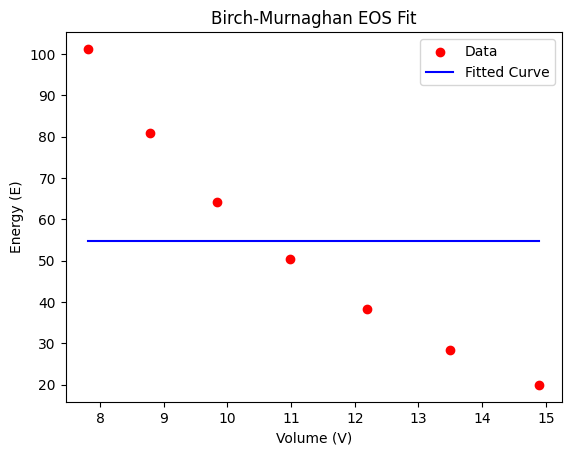

In [49]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define the Birch-Murnaghan EOS function
def birch_murnaghan(V, E0, V0, B0, B0_prime):
    term1 = (V0 / V)**(2/3) - 1
    term2 = (6 - 4 * (V0 / V)**(2/3))
    energy = E0 + (9/16) * V0 * B0 * (term1**3 * B0_prime + term1**2 * term2)
    return energy

# Example data (replace these arrays with your actual data)
# Volumes (V) and corresponding energies (E)
# Initialize lists to store r values and F (energy) values
r_values = []
energy_values= []
# Read the file
with open('energy2.dat', 'r') as file:
    for line in file:
        # Split the line by whitespace to access elements
        parts = line.split()
        
        # Extract r from the first column
        r = float(parts[0])  # r value
        
        # Find the 'F=' and capture the energy value after it
        energy_str = line.split('F=')[1].split()[0]  # Extract the string after 'F=' up to the next space
        energy = float(energy_str)  # Convert it to a float
        
        # Append values to respective lists
        r_values.append(r)
        energy_values.append(energy)
a = np.array(r_values)

volumes = 0.5*a**3 # Replace with your data
energies = np.array(energy_values)
print(len(energies))
print(len(volumes))
# Initial guesses for parameters: [E0, V0, B0, B0']
initial_guesses = [-1, 5, 1, 4]  # Adjust based on expected values

# Fit the Birch-Murnaghan equation to the data
params, covariance = curve_fit(birch_murnaghan, volumes, energies, p0=initial_guesses)

# Extract fitted parameters
E0_fit, V0_fit, B0_fit, B0_prime_fit = params

print("Fitted Parameters:")
print(f"E0: {E0_fit:.4f}")
print(f"V0: {V0_fit:.4f}")
print(f"B0: {B0_fit:.4f}")
print(f"B0': {B0_prime_fit:.4f}")

# Plot the data and the fitted curve
volumes_fit = np.linspace(min(volumes), max(volumes), 500)
energies_fit = birch_murnaghan(volumes_fit, *params)

plt.scatter(volumes, energies, label="Data", color="red")
plt.plot(volumes_fit, energies_fit, label="Fitted Curve", color="blue")
plt.xlabel("Volume (V)")
plt.ylabel("Energy (E)")
plt.legend()
plt.title("Birch-Murnaghan EOS Fit")
plt.show()


In [ ]:
Efcc = [101.26096, 80.977596, 64.21794, 50.303077, 38.441061, 28.420294,
         19.949626, 19.949626, 12.88038, 7.0789925, 2.41398, -1.2514826,
         -4.065029, -6.1630128, -7.6858134, -8.7577784, -9.4816905]
 